In [57]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [58]:
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [69]:
print(fetch_california_housing()['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [59]:
from sklearn.neighbors import KNeighborsRegressor

In [60]:
mod = KNeighborsRegressor()

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])

In [61]:
pipe.fit(X_train, y_train)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [62]:
pred = pipe.predict(X_test)

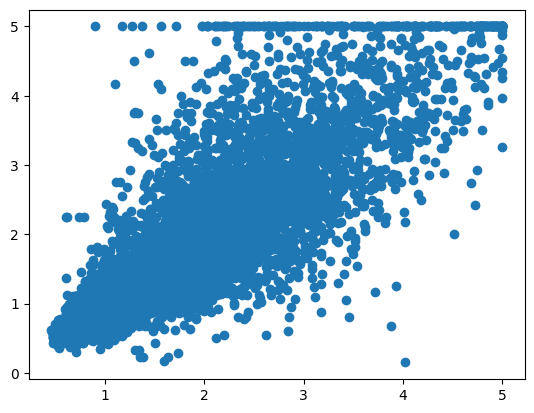

In [63]:
plt.scatter(pred, y_test)

In [64]:
pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [66]:
from sklearn.model_selection import GridSearchCV

mod = GridSearchCV(estimator=pipe, param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,10]}, cv=3)

In [68]:
mod.fit(X_train, y_train)
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.016755,0.004622,0.197942,0.048138,1,{'model__n_neighbors': 1},0.513895,0.534046,0.479337,0.509093,0.022591,10
1,0.015381,0.003591,0.195010,0.035334,2,{'model__n_neighbors': 2},0.619030,0.643654,0.601043,0.621242,0.017466,9
2,0.017240,0.004892,0.250941,0.036724,3,{'model__n_neighbors': 3},0.645893,0.671502,0.640726,0.652707,0.013456,8
3,0.020773,0.003833,0.318534,0.014461,4,{'model__n_neighbors': 4},0.661727,0.690109,0.653809,0.668549,0.015585,7
4,0.019522,0.002598,0.279444,0.034818,5,{'model__n_neighbors': 5},0.662940,0.696906,0.660985,0.673610,0.016492,6
5,0.018228,0.004034,0.294615,0.025716,6,{'model__n_neighbors': 6},0.670440,0.698659,0.666238,0.678446,0.014395,5
6,0.014373,0.004085,0.280009,0.040096,7,{'model__n_neighbors': 7},0.671792,0.700952,0.669464,0.680736,0.014326,4
7,0.021296,0.001085,0.323029,0.032307,8,{'model__n_neighbors': 8},0.672192,0.702829,0.669217,0.681413,0.015192,3
8,0.017936,0.004474,0.328765,0.030153,9,{'model__n_neighbors': 9},0.672827,0.703338,0.670123,0.682096,0.015061,2
9,0.015677,0.004805,0.329682,0.034372,10,{'model__n_neighbors': 10},0.673600,0.706042,0.670797,0.683480,0.015995,1
